In [36]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("multilinear-practice.csv")

print(df.head())

   StudyHours ExtraParticipation  PapersPracticed  PreviousMarks  \
0           5                 No                2             69   
1           2                Yes                8             46   
2           7                Yes                5             56   
3           6                Yes                5             42   
4           7                 No                6             53   

   SleepingHours  PerformanceIndex  
0              8                51  
1              4                20  
2              7                46  
3              8                28  
4              4                41  


In [3]:
df["ExtraParticipation"] = df['ExtraParticipation'].map(
    {
        "Yes": 1,
        "No": 0
    }
)

In [4]:
df.head()

,StudyHours,ExtraParticipation,PapersPracticed,PreviousMarks,SleepingHours,PerformanceIndex
0,5,0,2,69,8,51
1,2,1,8,46,4,20
2,7,1,5,56,7,46
3,6,1,5,42,8,28
4,7,0,6,53,4,41


In [ ]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = 0
        self.loss = []
        self._mean = None
        self._std = None

    @staticmethod
    def _mean_squared_error( y, y_hat):
        n = y.shape[0]
        error =  np.sum((y - y_hat) **2) / n

        return error 

    def _scale_features(self,X):
        self._mean = X.mean(axis=0)
        self._std = X.std(axis= 0)

        X_scaled = (X - self._mean) / self._std

        return X_scaled
    
    def _gradient_descent(self, X, y):
        de_dw = 0
        de_db = 0

        n = X.shape[0]

        y_hat = np.dot(X, self.weights) + self.bias

        de_dw = -(2/n) * np.dot( X.T , (y - y_hat))
        de_db = -(2/n) * np.sum(y - y_hat)

    
        
        self.weights -= self.learning_rate * de_dw
        self.bias -= self.learning_rate * de_db

    def fit(self,X,y):
        self.weights = np.zeros(X.shape[1])
        X = self._scale_features(X)
        for _ in range(self.n_iterations):
            self._gradient_descent(X,y)
            y_hat = np.dot(X, self.weights) + self.bias
            loss = self._mean_squared_error(y, y_hat)
            self.loss.append(loss)

    def predict(self,X):
        X = (X- self._mean) / self._std
        return np.dot(X, self.weights) + self.bias



In [65]:
target_label = ["PerformanceIndex"]
X = df.drop(columns = target_label)
y = df[target_label]

X = X.values.astype(float)
y = y.values.astype(float).ravel()
model = LinearRegression(n_iterations=1000)

model.fit(X,y)


In [66]:
print(model.weights)

[ 6.33136481  0.3097664   0.55568478 15.253034    0.73538004]


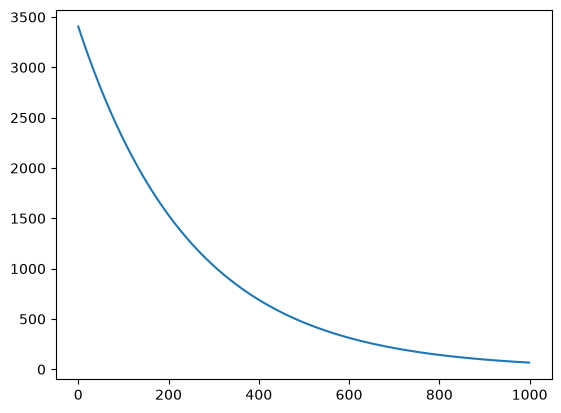

In [67]:
plt.plot(model.loss)
plt.show()

In [70]:
testing = np.array([
    [5,0,2,69,8],
    ])

print(model.predict(testing))

[47.22123154]
